## 1. Introduction

In [1]:
import os
import re
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss
from IPython.display import display

c:\Users\HP\Downloads\Omobobola Famosaya Dissertation\omobobola-project\omobobola-project\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================================
# Configuration
# =========================================================
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

BENCHMARK_DIR = "benchmark"
MODEL_ARTIFACT_DIR = "artifacts"
os.makedirs(MODEL_ARTIFACT_DIR, exist_ok=True)

# Retrieval hyperparameter tuning: fraction of qids (with qrels) held out for *tuning*
TUNING_DEV_FRACTION = 0.30

## 2. Functions

In [3]:


def to_text(x):
    if isinstance(x, list):
        return " ".join(map(str, x))
    if pd.isna(x):
        return ""
    return str(x)


def word_count(text):
    text = to_text(text).strip()
    return 0 if text == "" else len(text.split())


def char_count(text):
    return len(to_text(text))


def clean_lexical_text(text):
    text = to_text(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def safe_duplicate_count(frame):
    safe = frame.copy()
    for c in safe.columns:
        safe[c] = safe[c].apply(lambda v: json.dumps(v, sort_keys=True) if isinstance(v, (list, dict)) else v)
    return int(safe.duplicated().sum())


def add_stable_doc_id(frame):
    out = frame.reset_index(drop=True).copy()
    if "parent_asin" in out.columns:
        base_ids = out["parent_asin"].fillna("").astype(str).str.strip()
        base_ids = np.where(base_ids == "", "row_" + out.index.astype(str), base_ids)
    else:
        base_ids = "row_" + out.index.astype(str)

    base_ids = pd.Series(base_ids, dtype="string")
    dup_no = base_ids.groupby(base_ids).cumcount()
    out["doc_id"] = np.where(dup_no == 0, base_ids, base_ids + "__dup" + dup_no.astype(str))
    return out

## Data Loading

In [4]:
# Load frozen corpus prepared in product-data-preparation.ipynb
PRODUCTS_CSV = "data/products.csv"

if not os.path.exists(PRODUCTS_CSV):
    raise FileNotFoundError(
        "products.csv not found. Run product-data-preparation.ipynb first to generate it."
    )

df_raw = pd.read_csv(PRODUCTS_CSV)

print("Loaded rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
df_raw.head(3)

Loaded rows: 10000
Columns: 19


,doc_num,doc_id,parent_asin,source_category_file,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together,subtitle,author
0,1,B01CUPMQZE-NbrnTP3fAb,B01CUPMQZE,All Beauty,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,NaN,NaN,NaN
1,2,B076WQZGPM-nFbmOHnKYa,B076WQZGPM,All Beauty,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",NaN,NaN,NaN
2,3,B000B658RI-XRvj7uff0L,B000B658RI,All Beauty,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},NaN,NaN,NaN


## Data Exploration

Potential duplicate rows (safe check): 0
doc_id unique: 10000 / 10000
doc_id nulls: 0
Unique parent_asin groups: 10000
Avg variants per parent_asin: 1.0
title_empty_pct           0.01
description_empty_pct     0.00
features_empty_pct        0.00
combined_lt5_words_pct    0.11
dtype: float64


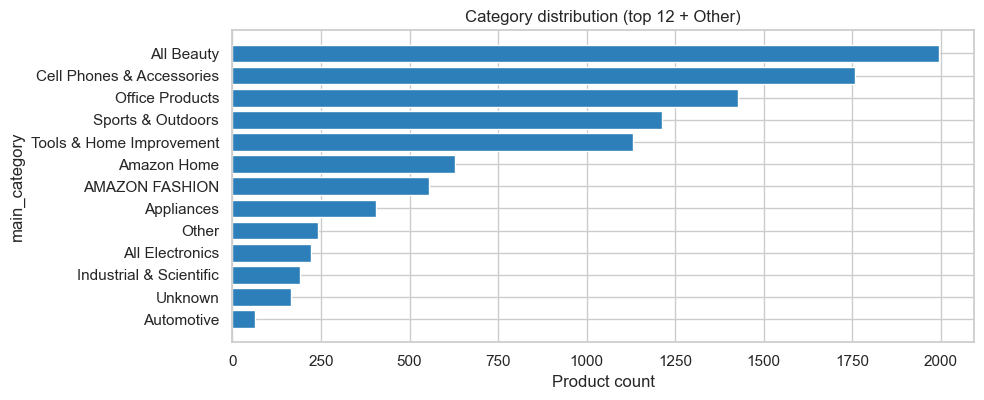

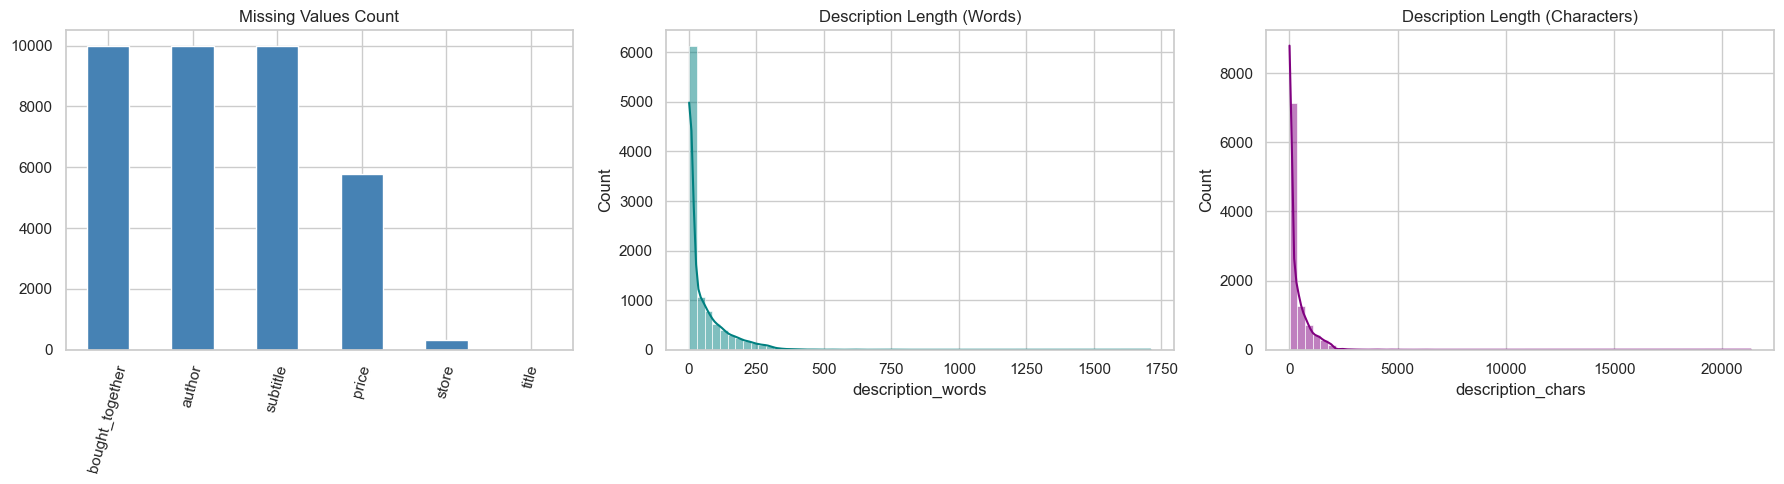

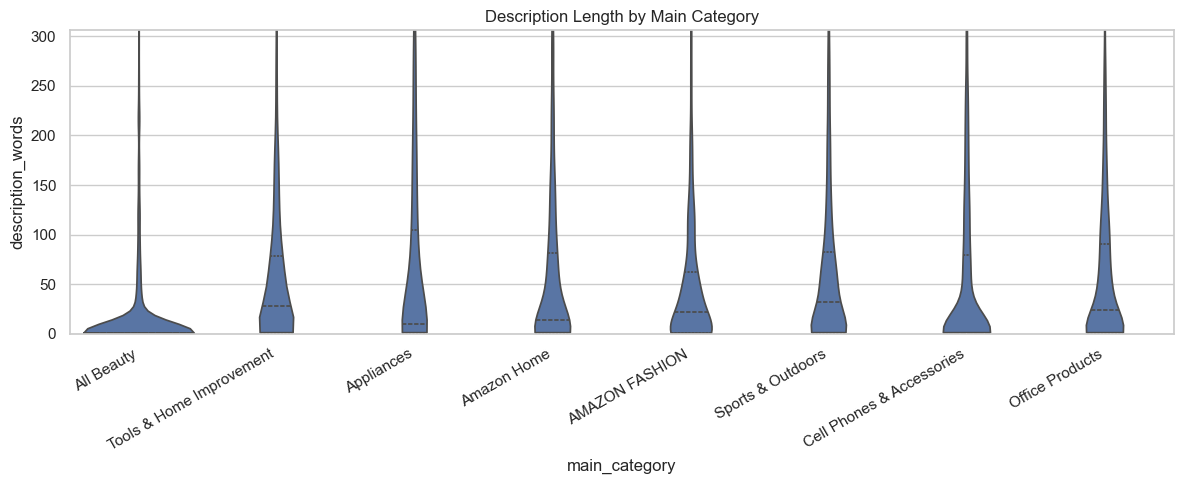

,description_words,description_chars,combined_words
count,10000.00000,10000.000000,10000.000000
mean,48.02980,311.446800,134.798700
std,80.65627,572.069902,130.982958
min,1.00000,2.000000,2.000000
50%,4.00000,29.000000,93.000000
90%,153.00000,988.100000,309.100000
95%,214.00000,1391.050000,388.050000
99%,308.00000,1967.000000,536.010000
max,1710.00000,21325.000000,1920.000000


In [5]:
eda_df = df_raw.copy()

missing = eda_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

dup_rows = safe_duplicate_count(eda_df)
print("Potential duplicate rows (safe check):", dup_rows)

# ID integrity checks
if "doc_id" in eda_df.columns:
    print("doc_id unique:", int(eda_df["doc_id"].nunique()), "/", int(len(eda_df)))
    print("doc_id nulls:", int(eda_df["doc_id"].isna().sum()))

# Variant structure check (parent_asin is umbrella id)
if "parent_asin" in eda_df.columns:
    parent_counts = eda_df["parent_asin"].fillna("no_parent").astype(str).str.strip().replace("", "no_parent").value_counts()
    print("Unique parent_asin groups:", int(parent_counts.shape[0]))
    print("Avg variants per parent_asin:", round(float(parent_counts.mean()), 2))

eda_df["title_txt"] = eda_df.get("title", "").apply(to_text)
eda_df["description_txt"] = eda_df.get("description", "").apply(to_text)
eda_df["features_txt"] = eda_df.get("features", "").apply(to_text)
eda_df["combined_text"] = (eda_df["title_txt"] + " " + eda_df["description_txt"] + " " + eda_df["features_txt"]).str.strip()

eda_df["description_words"] = eda_df["description_txt"].apply(word_count)
eda_df["description_chars"] = eda_df["description_txt"].apply(char_count)
eda_df["combined_words"] = eda_df["combined_text"].apply(word_count)

# Field completeness profile
field_empty_profile = {
    "title_empty_pct": float((eda_df["title_txt"].str.strip() == "").mean() * 100),
    "description_empty_pct": float((eda_df["description_txt"].str.strip() == "").mean() * 100),
    "features_empty_pct": float((eda_df["features_txt"].str.strip() == "").mean() * 100),
    "combined_lt5_words_pct": float((eda_df["combined_words"] < 5).mean() * 100),
}
print(pd.Series(field_empty_profile).round(2))

# Category distribution (main_category)
if "main_category" in eda_df.columns:
    top_n = 12
    cat_s = eda_df["main_category"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
    vc = cat_s.value_counts()
    if len(vc) > top_n:
        tail = int(vc.iloc[top_n:].sum())
        plot_vc = pd.concat([vc.head(top_n), pd.Series({"Other": tail})])
    else:
        plot_vc = vc
    plot_vc = plot_vc.sort_values(ascending=True)
    plt.figure(figsize=(10, max(4, 0.32 * len(plot_vc))))
    plt.barh(plot_vc.index.astype(str), plot_vc.values, color="#2c7fb8")
    plt.xlabel("Product count")
    plt.ylabel("main_category")
    plt.title(
        f"Category distribution (top {top_n} + Other)"
        if len(vc) > top_n
        else "Category distribution (main_category)"
    )
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if len(missing) > 0:
    missing.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Missing Values Count")
axes[0].tick_params(axis="x", rotation=75)

sns.histplot(eda_df["description_words"], bins=60, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Description Length (Words)")

sns.histplot(eda_df["description_chars"], bins=60, kde=True, ax=axes[2], color="purple")
axes[2].set_title("Description Length (Characters)")

plt.tight_layout()
plt.show()

top_cats = eda_df["main_category"].fillna("Unknown").value_counts().head(8).index
cat_df = eda_df[eda_df["main_category"].fillna("Unknown").isin(top_cats)].copy()
cat_df["main_category"] = cat_df["main_category"].fillna("Unknown")

plt.figure(figsize=(12, 5))
sns.violinplot(data=cat_df, x="main_category", y="description_words", inner="quartile", cut=0)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, np.percentile(cat_df["description_words"], 99))
plt.title("Description Length by Main Category")
plt.tight_layout()
plt.show()

eda_df[["description_words", "description_chars", "combined_words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

## Data Cleaning

In [6]:
df = df_raw.copy()

# Fill missing values for retrieval-relevant fields
for c in ["title", "description", "features", "main_category", "store"]:
    if c in df.columns:
        fill_value = "Unknown" if c == "main_category" else ""
        df[c] = df[c].fillna(fill_value)

# Normalize list-like fields to text
for c in ["description", "features", "categories"]:
    if c in df.columns:
        df[c] = df[c].apply(to_text)

# Build combined text now for quality filtering
df["combined_text"] = (df["title"].apply(to_text) + " " + df["description"] + " " + df["features"]).str.strip()

before_rows = len(df)

# Remove empty retrieval documents
df = df[df["combined_text"].str.strip() != ""].copy()

# Keep prepared doc_id from products.csv; only create fallback if missing
if "doc_id" not in df.columns:
    df = add_stable_doc_id(df)

# Only remove exact duplicated doc_id rows if they appear.
if "doc_id" in df.columns:
    df = df.drop_duplicates(subset=["doc_id"], keep="first")

df = df.reset_index(drop=True)

print(f"Rows before cleaning: {before_rows}")
print(f"Rows after cleaning: {len(df)}")
print("Unique doc_id:", df["doc_id"].nunique())

df.head(3)

Rows before cleaning: 10000
Rows after cleaning: 10000
Unique doc_id: 10000


,doc_num,doc_id,parent_asin,source_category_file,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together,subtitle,author,combined_text
0,1,B01CUPMQZE-NbrnTP3fAb,B01CUPMQZE,All Beauty,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,NaN,NaN,NaN,"Howard LC0008 Leather Conditioner, 8-Ounce (4-..."
1,2,B076WQZGPM-nFbmOHnKYa,B076WQZGPM,All Beauty,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",NaN,NaN,NaN,Yes to Tomatoes Detoxifying Charcoal Cleanser ...
2,3,B000B658RI-XRvj7uff0L,B000B658RI,All Beauty,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},NaN,NaN,NaN,Eye Patch Black Adult with Tie Band (6 Per Pac...


## Preprocessing

In [7]:
# Build lexical and semantic text variants

df["lexical_text"] = df["combined_text"].apply(clean_lexical_text)
# Keep semantic text relatively natural; only collapse excessive whitespace
df["semantic_text"] = df["combined_text"].apply(lambda t: re.sub(r"\s+", " ", to_text(t)).strip())

# Parse numeric analysis fields once (useful for diagnostics and later analysis)
for num_col in ["price", "rating_number", "average_rating"]:
    if num_col in df.columns:
        df[num_col] = pd.to_numeric(df[num_col], errors="coerce")

pre_rows = len(df)

# Safety filter: keep records with usable lexical and semantic content
df = df[(df["lexical_text"].str.strip() != "") & (df["semantic_text"].str.strip() != "")].reset_index(drop=True)

# Keep id arrays for retrieval wrappers
idx_to_doc_id = df["doc_id"].to_numpy()
doc_id_set = set(idx_to_doc_id)

print("Preprocessing stats")
print("- rows before:", pre_rows)
print("- rows after:", len(df))
print("- pct dropped:", round((1 - len(df) / pre_rows) * 100, 2) if pre_rows else 0)
print("- avg lexical words:", round(df["lexical_text"].str.split().str.len().mean(), 2))
print("- avg semantic words:", round(df["semantic_text"].str.split().str.len().mean(), 2))

print(df[["doc_id", "title", "main_category", "lexical_text"]].head(2))

Preprocessing stats
- rows before: 10000
- rows after: 9998
- pct dropped: 0.02
- avg lexical words: 139.56
- avg semantic words: 134.83
                  doc_id                                              title  \
0  B01CUPMQZE-NbrnTP3fAb  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1  B076WQZGPM-nFbmOHnKYa  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   

  main_category                                       lexical_text  
0    All Beauty   howard lc0008 leather conditioner 8 ounce 4 pack  
1    All Beauty  yes to tomatoes detoxifying charcoal cleanser ...  


## Retrieval: benchmark split, hyperparameter tuning, and indices

We **tune on a development slice** of benchmark queries (with qrels), then **fit final models on the full corpus** and **report metrics on the held-out test slice**.

- **BM25**: grid over Okapi **k1**, **b**, and **epsilon**.
- **SBERT / E5**: small **model-name** grids (and fixed encoding settings per family).
- **Dense winner**: the better of best-SBERT vs best-E5 on the dev objective becomes the **semantic leg** in **hybrid RRF**.
- **Hybrid**: after fixing lexical + dense legs, we grid **RRF k₀** and **pool size** on the dev set.


In [8]:
# Benchmark loading, metrics, dev/test split
# Required files:
#   benchmark/queries.csv -> query_id, query_text
#   benchmark/qrels.csv   -> query_id, doc_id, relevance

queries_path = os.path.join(BENCHMARK_DIR, "queries.csv")
qrels_path = os.path.join(BENCHMARK_DIR, "qrels.csv")

if not (os.path.exists(queries_path) and os.path.exists(qrels_path)):
    raise FileNotFoundError(
        "Create benchmark/queries.csv and benchmark/qrels.csv before evaluation."
    )

queries_df = pd.read_csv(queries_path)
qrels_df = pd.read_csv(qrels_path)

queries_df["query_id"] = queries_df["query_id"].astype(str)
qrels_df["query_id"] = qrels_df["query_id"].astype(str)
qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)
qrels_df["relevance"] = qrels_df["relevance"].astype(float)

qrels_df = qrels_df[qrels_df["doc_id"].isin(doc_id_set)].copy()


def build_rel_judgements(qrels):
    rel = defaultdict(dict)
    for r in qrels.itertuples(index=False):
        rel[r.query_id][r.doc_id] = float(r.relevance)
    return rel


def precision_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    ranked = ranked_ids[:k]
    denom = min(k, len(ranked_ids))
    if denom == 0:
        return 0.0
    hits = sum(1 for d in ranked if rel_map.get(d, 0) >= rel_threshold)
    return hits / denom


def recall_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    total_rel = sum(1 for _, r in rel_map.items() if r >= rel_threshold)
    if total_rel == 0:
        return 0.0
    hits = sum(1 for d in ranked_ids[:k] if rel_map.get(d, 0) >= rel_threshold)
    return hits / total_rel


def reciprocal_rank_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    for rank, d in enumerate(ranked_ids[:k], start=1):
        if rel_map.get(d, 0) >= rel_threshold:
            return 1.0 / rank
    return 0.0


def average_precision_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    ranked = ranked_ids[:k]
    total_rel = sum(1 for _, r in rel_map.items() if r >= rel_threshold)
    if total_rel == 0:
        return 0.0

    hit_count = 0
    precision_sum = 0.0
    for i, d in enumerate(ranked, start=1):
        if rel_map.get(d, 0) >= rel_threshold:
            hit_count += 1
            precision_sum += hit_count / i
    return precision_sum / min(total_rel, k)


def ndcg_at_k(ranked_ids, rel_map, k=10):
    gains = np.array([rel_map.get(d, 0.0) for d in ranked_ids[:k]], dtype=np.float32)
    discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float(np.sum(gains * discounts))

    ideal = np.array(sorted(rel_map.values(), reverse=True)[:k], dtype=np.float32)
    ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal) + 2))
    idcg = float(np.sum(ideal * ideal_discounts))
    return 0.0 if idcg == 0 else dcg / idcg


def evaluate_system(name, retrieve_fn, queries, qrels):
    rel = build_rel_judgements(qrels)
    rows = []
    latency_ms = []

    for q in queries.itertuples(index=False):
        qid = str(q.query_id)
        qtext = q.query_text
        if qid not in rel:
            continue

        t0 = time.perf_counter()
        ranked = retrieve_fn(qtext, top_k=10)
        latency_ms.append((time.perf_counter() - t0) * 1000)

        ranked_ids = [doc_id for doc_id, _ in ranked]
        rel_map = rel[qid]

        rows.append({
            "system": name,
            "query_id": qid,
            "p@5": precision_at_k(ranked_ids, rel_map, 5),
            "recall@5": recall_at_k(ranked_ids, rel_map, 5),
            "mrr@5": reciprocal_rank_at_k(ranked_ids, rel_map, 5),
            "map@5": average_precision_at_k(ranked_ids, rel_map, 5),
            "ndcg@5": ndcg_at_k(ranked_ids, rel_map, 5),
            "p@10": precision_at_k(ranked_ids, rel_map, 10),
            "recall@10": recall_at_k(ranked_ids, rel_map, 10),
            "mrr@10": reciprocal_rank_at_k(ranked_ids, rel_map, 10),
            "map@10": average_precision_at_k(ranked_ids, rel_map, 10),
            "ndcg@10": ndcg_at_k(ranked_ids, rel_map, 10),
            "latency_ms": latency_ms[-1],
        })

    per_query = pd.DataFrame(rows)
    if per_query.empty:
        raise ValueError("No evaluated rows. Check qrels coverage and doc_id alignment.")
    summary = per_query.drop(columns=["system", "query_id"]).mean().to_frame(name=name).T
    return per_query, summary


def _better_summary(s_a, s_b, primary="ndcg@10", tie="map@10"):
    if s_a[primary] != s_b[primary]:
        return s_a[primary] > s_b[primary]
    return s_a[tie] > s_b[tie]


# --- Reproducible dev/test split on queries that have qrels ---
TUNING_SEED = SEED

qids_with_rel = sorted(qrels_df["query_id"].unique())
rng = np.random.default_rng(TUNING_SEED)
perm = rng.permutation(len(qids_with_rel))
qids_arr = np.array(qids_with_rel)[perm]

n = len(qids_arr)
n_dev = int(round(n * TUNING_DEV_FRACTION))
n_dev = max(1, min(n_dev, n - 1))

dev_qids = set(qids_arr[:n_dev].tolist())
test_qids = set(qids_arr[n_dev:].tolist())

queries_dev = queries_df[queries_df["query_id"].isin(dev_qids)].copy()
queries_test = queries_df[queries_df["query_id"].isin(test_qids)].copy()
qrels_dev = qrels_df[qrels_df["query_id"].isin(dev_qids)].copy()
qrels_test = qrels_df[qrels_df["query_id"].isin(test_qids)].copy()

print("Queries (file):", len(queries_df), "| Qrels rows:", len(qrels_df))
print("Distinct qids with qrels:", n)
print(
    f"Dev/Test split: dev={len(dev_qids)} qids, test={len(test_qids)} qids "
    f"(fraction≈{TUNING_DEV_FRACTION:.2f}, seed={TUNING_SEED})"
)
queries_df.head(3)


Queries (file): 100 | Qrels rows: 2082
Distinct qids with qrels: 100
Dev/Test split: dev=30 qids, test=70 qids (fraction≈0.30, seed=42)


,query_id,query_text,intent,primary_category,difficulty
0,Q001,acne face cleanser for oily skin,feature-based,All Beauty,easy
1,Q002,matte foundation for dark skin tone,feature-based,All Beauty,medium
2,Q003,sulfate free baby shampoo,feature-based,All Beauty,easy


### Hyperparameter search (development queries)

Grids are intentionally small so the notebook stays tractable; expand `BM25_GRID`, `SBERT_CANDIDATES`, and `E5_CANDIDATES` for a fuller search.


In [9]:
# Corpus tokenization for BM25 (fixed lexical field)
bm25_corpus = [doc.split() for doc in df["lexical_text"].tolist()]
semantic_texts = df["semantic_text"].tolist()
ENCODE_BATCH_SIZE = 64

# ---------------- BM25 grid ----------------
BM25_GRID = [
    {"k1": k1, "b": b, "epsilon": eps}
    for k1 in [1.2, 1.5, 2.0]
    for b in [0.5, 0.75, 0.9]
    for eps in [0.25]
]

bm25_tune_rows = []
for p in BM25_GRID:
    bm = BM25Okapi(bm25_corpus, k1=p["k1"], b=p["b"], epsilon=p["epsilon"])

    def _bm25_retrieve_tune(query, top_k=10, _bm=bm):
        tokens = clean_lexical_text(query).split()
        scores = np.asarray(_bm.get_scores(tokens), dtype=np.float32)
        k = min(top_k, len(scores))
        if k == 0:
            return []
        idx = np.argpartition(-scores, kth=k - 1)[:k]
        idx = idx[np.argsort(-scores[idx])]
        return [(idx_to_doc_id[i], float(scores[i])) for i in idx]

    _, summ = evaluate_system(
        f"BM25_tune_k1={p['k1']}_b={p['b']}", _bm25_retrieve_tune, queries_dev, qrels_dev
    )
    row = {**p, **summ.iloc[0].to_dict()}
    bm25_tune_rows.append(row)

bm25_tune_df = pd.DataFrame(bm25_tune_rows)
best_bm25_row = bm25_tune_df.sort_values(
    ["ndcg@10", "map@10"], ascending=[False, False], kind="mergesort"
).iloc[0]

BEST_BM25 = {
    "k1": float(best_bm25_row["k1"]),
    "b": float(best_bm25_row["b"]),
    "epsilon": float(best_bm25_row["epsilon"]),
}
print("BM25 tuning (dev) — best:", BEST_BM25)
display(bm25_tune_df.sort_values("ndcg@10", ascending=False).head(10))



BM25 tuning (dev) — best: {'k1': 1.5, 'b': 0.75, 'epsilon': 0.25}


,k1,b,epsilon,p@5,recall@5,mrr@5,map@5,ndcg@5,p@10,recall@10,mrr@10,map@10,ndcg@10,latency_ms
4,1.5,0.75,0.25,0.846667,0.298920,0.966667,0.811444,0.820362,0.813333,0.559880,0.966667,0.766877,0.817201,25.390537
1,1.2,0.75,0.25,0.853333,0.302768,0.977778,0.822333,0.828723,0.800000,0.552165,0.977778,0.753702,0.814111,25.878150
7,2.0,0.75,0.25,0.860000,0.302871,0.950000,0.822556,0.821227,0.780000,0.539777,0.950000,0.738617,0.794934,25.916803
2,1.2,0.90,0.25,0.846667,0.296045,0.983333,0.812000,0.817151,0.756667,0.522099,0.983333,0.707967,0.776292,25.036047
5,1.5,0.90,0.25,0.846667,0.300860,0.983333,0.810556,0.819982,0.730000,0.505613,0.983333,0.686374,0.758926,26.371807
0,1.2,0.50,0.25,0.840000,0.298193,0.977778,0.813222,0.819626,0.703333,0.490156,0.977778,0.669308,0.751747,25.246200
3,1.5,0.50,0.25,0.853333,0.299737,0.961111,0.818333,0.817758,0.703333,0.490265,0.961111,0.669227,0.748815,25.774533
6,2.0,0.50,0.25,0.866667,0.302853,0.950000,0.829444,0.822218,0.696667,0.486932,0.950000,0.662970,0.740785,25.505860
8,2.0,0.90,0.25,0.813333,0.284567,0.950000,0.769222,0.786810,0.706667,0.493585,0.950000,0.653919,0.734463,25.760303


In [10]:
# ---------------- Dense encoders (SBERT vs E5 families) ----------------
def build_dense_stack(family, model_name):
    family = family.lower()
    model = SentenceTransformer(model_name)
    if family == "sbert":
        emb = model.encode(
            semantic_texts, show_progress_bar=True, batch_size=ENCODE_BATCH_SIZE
        )
    elif family == "e5":
        passages = ["passage: " + t for t in semantic_texts]
        emb = model.encode(
            passages, show_progress_bar=True, batch_size=ENCODE_BATCH_SIZE
        )
    else:
        raise ValueError(family)

    emb = np.asarray(emb, dtype=np.float32)
    index = faiss.IndexFlatL2(emb.shape[1])
    index.add(emb)
    return model, index, emb


def make_dense_retriever(family, model, index):
    family = family.lower()

    def retrieve(query, top_k=10):
        if family == "sbert":
            q = np.asarray(model.encode([to_text(query)]), dtype=np.float32)
        else:
            q = np.asarray(
                model.encode(["query: " + to_text(query)]), dtype=np.float32
            )
        distances, indices = index.search(q, top_k)
        out = []
        for d, i in zip(distances[0], indices[0]):
            if i != -1:
                out.append((idx_to_doc_id[i], float(-d)))
        return out

    return retrieve


SBERT_CANDIDATES = [
    "all-MiniLM-L6-v2",
    "multi-qa-MiniLM-L6-cos-v1",
]
E5_CANDIDATES = [
    "intfloat/e5-small-v2",
    "intfloat/e5-base-v2",
]

sbert_tune_rows = []
best_sbert = None
best_sbert_score = None

for mname in SBERT_CANDIDATES:
    smodel, sidx, semb = build_dense_stack("sbert", mname)
    s_ret = make_dense_retriever("sbert", smodel, sidx)
    _, summ = evaluate_system(f"SBERT_tune_{mname}", s_ret, queries_dev, qrels_dev)
    s_row = {"family": "sbert", "model_name": mname, **summ.iloc[0].to_dict()}
    sbert_tune_rows.append(s_row)
    s_series = summ.iloc[0]
    if best_sbert_score is None or _better_summary(s_series, best_sbert_score):
        best_sbert_score = s_series
        best_sbert = {"family": "sbert", "model_name": mname}
    del smodel, sidx, semb, s_ret

sbert_tune_df = pd.DataFrame(sbert_tune_rows)
print("SBERT tuning (dev) — best:", best_sbert)
display(sbert_tune_df.sort_values("ndcg@10", ascending=False))

e5_tune_rows = []
best_e5 = None
best_e5_score = None

for mname in E5_CANDIDATES:
    emodel, eidx, eemb = build_dense_stack("e5", mname)
    e_ret = make_dense_retriever("e5", emodel, eidx)
    _, summ = evaluate_system(f"E5_tune_{mname}", e_ret, queries_dev, qrels_dev)
    e_row = {"family": "e5", "model_name": mname, **summ.iloc[0].to_dict()}
    e5_tune_rows.append(e_row)
    e_series = summ.iloc[0]
    if best_e5_score is None or _better_summary(e_series, best_e5_score):
        best_e5_score = e_series
        best_e5 = {"family": "e5", "model_name": mname}
    del emodel, eidx, eemb, e_ret

e5_tune_df = pd.DataFrame(e5_tune_rows)
print("E5 tuning (dev) — best:", best_e5)
display(e5_tune_df.sort_values("ndcg@10", ascending=False))

# Semantic leg for hybrid: better of the two family winners (on dev)
if _better_summary(best_sbert_score, best_e5_score):
    BEST_DENSE_FOR_HYBRID = dict(best_sbert)
    print("Hybrid semantic leg (dev): SBERT wins →", BEST_DENSE_FOR_HYBRID)
else:
    BEST_DENSE_FOR_HYBRID = dict(best_e5)
    print("Hybrid semantic leg (dev): E5 wins →", BEST_DENSE_FOR_HYBRID)




Batches: 100%|██████████| 157/157 [11:12<00:00,  4.29s/it]
c:\Users\HP\Downloads\Omobobola Famosaya Dissertation\omobobola-project\omobobola-project\.conda\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--sentence-transformers--multi-qa-MiniLM-L6-cos-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-devel

SBERT tuning (dev) — best: {'family': 'sbert', 'model_name': 'all-MiniLM-L6-v2'}


,family,model_name,p@5,recall@5,mrr@5,map@5,ndcg@5,p@10,recall@10,mrr@10,map@10,ndcg@10,latency_ms
0,sbert,all-MiniLM-L6-v2,0.846667,0.287335,0.944444,0.814111,0.781866,0.813333,0.542069,0.944444,0.773188,0.780540,16.138843
1,sbert,multi-qa-MiniLM-L6-cos-v1,0.673333,0.225563,0.877778,0.619444,0.649528,0.586667,0.393225,0.877778,0.510930,0.613909,28.154193


c:\Users\HP\Downloads\Omobobola Famosaya Dissertation\omobobola-project\omobobola-project\.conda\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--intfloat--e5-small-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet'

E5 tuning (dev) — best: {'family': 'e5', 'model_name': 'intfloat/e5-base-v2'}


,family,model_name,p@5,recall@5,mrr@5,map@5,ndcg@5,p@10,recall@10,mrr@10,map@10,ndcg@10,latency_ms
1,e5,intfloat/e5-base-v2,0.813333,0.286547,1.0,0.778111,0.791832,0.686667,0.470382,1.0,0.638988,0.729579,76.570233
0,e5,intfloat/e5-small-v2,0.733333,0.253022,1.0,0.699333,0.712423,0.633333,0.433368,1.0,0.577983,0.673750,63.932753


Hybrid semantic leg (dev): SBERT wins → {'family': 'sbert', 'model_name': 'all-MiniLM-L6-v2'}


In [11]:
# ---------------- Hybrid RRF (dev): tune k0, pool_k ----------------
bm25_dev = BM25Okapi(bm25_corpus, **BEST_BM25)


def bm25_retrieve_dev(query, top_k=10):
    tokens = clean_lexical_text(query).split()
    scores = np.asarray(bm25_dev.get_scores(tokens), dtype=np.float32)
    k = min(top_k, len(scores))
    if k == 0:
        return []
    idx = np.argpartition(-scores, kth=k - 1)[:k]
    idx = idx[np.argsort(-scores[idx])]
    return [(idx_to_doc_id[i], float(scores[i])) for i in idx]


hd_model, hd_index, _ = build_dense_stack(
    BEST_DENSE_FOR_HYBRID["family"], BEST_DENSE_FOR_HYBRID["model_name"]
)
dense_retrieve_dev = make_dense_retriever(
    BEST_DENSE_FOR_HYBRID["family"], hd_model, hd_index
)

HYBRID_GRID = [
    {"k0": 30, "pool_k": 50},
    {"k0": 60, "pool_k": 100},
    {"k0": 100, "pool_k": 100},
]

hybrid_tune_rows = []
best_hybrid_params = None
best_hybrid_score = None

for hp in HYBRID_GRID:
    k0 = hp["k0"]
    pool_k = hp["pool_k"]

    def _rrf_tune(query, top_k=10, _k0=k0, _pool=pool_k):
        bm = bm25_retrieve_dev(query, top_k=_pool)
        dn = dense_retrieve_dev(query, top_k=_pool)
        scores = defaultdict(float)
        for rank, (doc_id, _) in enumerate(bm, start=1):
            scores[doc_id] += 1.0 / (_k0 + rank)
        for rank, (doc_id, _) in enumerate(dn, start=1):
            scores[doc_id] += 1.0 / (_k0 + rank)
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return ranked

    _, summ = evaluate_system(
        f"Hybrid_tune_k0={k0}_pool={pool_k}", _rrf_tune, queries_dev, qrels_dev
    )
    hybrid_tune_rows.append({**hp, **summ.iloc[0].to_dict()})
    h_series = summ.iloc[0]
    if best_hybrid_score is None or _better_summary(h_series, best_hybrid_score):
        best_hybrid_score = h_series
        best_hybrid_params = dict(hp)

hybrid_tune_df = pd.DataFrame(hybrid_tune_rows)
BEST_HYBRID_RRF = dict(best_hybrid_params)
print("Hybrid RRF tuning (dev) — best:", BEST_HYBRID_RRF)
display(hybrid_tune_df.sort_values("ndcg@10", ascending=False))

# Drop large dev-only encoder to free memory before final fit
del hd_model, hd_index


Batches: 100%|██████████| 157/157 [20:07<00:00,  7.69s/it]  


Hybrid RRF tuning (dev) — best: {'k0': 30, 'pool_k': 50}


,k0,pool_k,p@5,recall@5,mrr@5,map@5,ndcg@5,p@10,recall@10,mrr@10,map@10,ndcg@10,latency_ms
0,30,50,0.866667,0.304003,0.966667,0.835667,0.830972,0.756667,0.514847,0.966667,0.724887,0.791761,72.887113
1,60,100,0.866667,0.304003,0.966667,0.834333,0.830513,0.753333,0.519279,0.966667,0.723745,0.788605,55.664083
2,100,100,0.866667,0.304003,0.966667,0.835000,0.830976,0.740000,0.507602,0.966667,0.714217,0.782543,55.842683


### Final retrieval models (full corpus, best hyperparameters)

We refit **BM25**, the **best SBERT**, and the **best E5** on the **entire** preprocessed catalog. The hybrid system uses **tuned BM25** + the **dev-selected dense leg** with **tuned RRF** settings.


In [12]:
# --- BM25 (full corpus) ---
bm25 = BM25Okapi(bm25_corpus, **BEST_BM25)
print("BM25 (final) docs:", len(bm25_corpus), "| params:", BEST_BM25)

# --- Best SBERT (full corpus) ---
sbert_model_name = best_sbert["model_name"]
sbert_model = SentenceTransformer(sbert_model_name)
sbert_embeddings = sbert_model.encode(
    semantic_texts, show_progress_bar=True, batch_size=ENCODE_BATCH_SIZE
)
sbert_embeddings = np.asarray(sbert_embeddings, dtype=np.float32)
sbert_index = faiss.IndexFlatL2(sbert_embeddings.shape[1])
sbert_index.add(sbert_embeddings)
print("SBERT (final):", sbert_model_name, "| index:", sbert_index.ntotal)

# --- Best E5 (full corpus) ---
e5_model_name = best_e5["model_name"]
e5_model = SentenceTransformer(e5_model_name)
e5_passages = ["passage: " + t for t in semantic_texts]
e5_embeddings = e5_model.encode(
    e5_passages, show_progress_bar=True, batch_size=ENCODE_BATCH_SIZE
)
e5_embeddings = np.asarray(e5_embeddings, dtype=np.float32)
e5_index = faiss.IndexFlatL2(e5_embeddings.shape[1])
e5_index.add(e5_embeddings)
print("E5 (final):", e5_model_name, "| index:", e5_index.ntotal)

# Persist tuning decisions for the write-up
retrieval_config = {
    "tuning": {
        "dev_fraction": TUNING_DEV_FRACTION,
        "seed": TUNING_SEED,
        "bm25": BEST_BM25,
        "best_sbert": best_sbert,
        "best_e5": best_e5,
        "hybrid_dense_leg": BEST_DENSE_FOR_HYBRID,
        "hybrid_rrf": BEST_HYBRID_RRF,
    },
    "final_models": {
        "sbert_model_name": sbert_model_name,
        "e5_model_name": e5_model_name,
    },
}
with open(os.path.join(BENCHMARK_DIR, "retrieval_config.json"), "w", encoding="utf-8") as f:
    json.dump(retrieval_config, f, indent=2)
print("Wrote", os.path.join(BENCHMARK_DIR, "retrieval_config.json"))


BM25 (final) docs: 9998 | params: {'k1': 1.5, 'b': 0.75, 'epsilon': 0.25}


Batches: 100%|██████████| 157/157 [11:39<00:00,  4.46s/it]


SBERT (final): all-MiniLM-L6-v2 | index: 9998


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 1f25c926-9b35-422d-989e-9727683c7b06)')' thrown while requesting HEAD https://huggingface.co/intfloat/e5-base-v2/resolve/main/README.md
Retrying in 1s [Retry 1/5].
Batches: 100%|██████████| 157/157 [2:16:29<00:00, 52.16s/it] 


E5 (final): intfloat/e5-base-v2 | index: 9998
Wrote benchmark\retrieval_config.json


In [13]:
# Retrieval wrappers + hybrid RRF (test evaluation uses these)


def bm25_retrieve(query, top_k=10):
    tokens = clean_lexical_text(query).split()
    scores = np.asarray(bm25.get_scores(tokens), dtype=np.float32)
    k = min(top_k, len(scores))
    if k == 0:
        return []
    idx = np.argpartition(-scores, kth=k - 1)[:k]
    idx = idx[np.argsort(-scores[idx])]
    return [(idx_to_doc_id[i], float(scores[i])) for i in idx]


def sbert_retrieve(query, top_k=10):
    q = np.asarray(sbert_model.encode([to_text(query)]), dtype=np.float32)
    distances, indices = sbert_index.search(q, top_k)
    out = []
    for d, i in zip(distances[0], indices[0]):
        if i != -1:
            out.append((idx_to_doc_id[i], float(-d)))
    return out


def e5_retrieve(query, top_k=10):
    q = np.asarray(e5_model.encode(["query: " + to_text(query)]), dtype=np.float32)
    distances, indices = e5_index.search(q, top_k)
    out = []
    for d, i in zip(distances[0], indices[0]):
        if i != -1:
            out.append((idx_to_doc_id[i], float(-d)))
    return out


RRF_K0 = int(BEST_HYBRID_RRF["k0"])
RRF_POOL_K = int(BEST_HYBRID_RRF["pool_k"])

if BEST_DENSE_FOR_HYBRID["family"] == "sbert":

    def _dense_for_hybrid(query, top_k=10):
        return sbert_retrieve(query, top_k=top_k)

    HYBRID_DENSE_LABEL = "SBERT"
else:

    def _dense_for_hybrid(query, top_k=10):
        return e5_retrieve(query, top_k=top_k)

    HYBRID_DENSE_LABEL = "E5"


def rrf_hybrid_retrieve(query, top_k=10, pool_k=None, k0=None):
    pool_k = RRF_POOL_K if pool_k is None else pool_k
    k0 = RRF_K0 if k0 is None else k0
    bm = bm25_retrieve(query, top_k=pool_k)
    dn = _dense_for_hybrid(query, top_k=pool_k)
    scores = defaultdict(float)
    for rank, (doc_id, _) in enumerate(bm, start=1):
        scores[doc_id] += 1.0 / (k0 + rank)
    for rank, (doc_id, _) in enumerate(dn, start=1):
        scores[doc_id] += 1.0 / (k0 + rank)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return ranked


HYBRID_SYSTEM_NAME = f"Hybrid_RRF_BM25_{HYBRID_DENSE_LABEL}"
print("Hybrid configuration:", HYBRID_SYSTEM_NAME, "| RRF k0=", RRF_K0, "pool_k=", RRF_POOL_K)


Hybrid configuration: Hybrid_RRF_BM25_SBERT | RRF k0= 30 pool_k= 50


## Evaluation (held-out test queries)

Metrics use the **same** `top_k=10` ranking as tuning; systems differ only by retriever and the hyperparameters selected on the **dev** split.


In [14]:
bm25_perq, bm25_summary = evaluate_system("BM25", bm25_retrieve, queries_test, qrels_test)
sbert_perq, sbert_summary = evaluate_system(
    f"SBERT ({sbert_model_name})", sbert_retrieve, queries_test, qrels_test
)
e5_perq, e5_summary = evaluate_system(
    f"E5 ({e5_model_name})", e5_retrieve, queries_test, qrels_test
)
hybrid_perq, hybrid_summary = evaluate_system(
    HYBRID_SYSTEM_NAME, rrf_hybrid_retrieve, queries_test, qrels_test
)

summary = pd.concat([bm25_summary, sbert_summary, e5_summary, hybrid_summary], axis=0)
summary


,p@5,recall@5,mrr@5,map@5,ndcg@5,p@10,recall@10,mrr@10,map@10,ndcg@10,latency_ms
BM25,0.825714,0.347181,0.961905,0.819821,0.807864,0.758571,0.591463,0.961905,0.769009,0.805096,36.328647
SBERT (all-MiniLM-L6-v2),0.805714,0.339546,0.950000,0.784198,0.761349,0.721429,0.561564,0.950000,0.710822,0.756104,21.605271
E5 (intfloat/e5-base-v2),0.768571,0.337595,0.954762,0.748722,0.763485,0.647143,0.533027,0.956548,0.636426,0.726400,74.560040
Hybrid_RRF_BM25_SBERT,0.814286,0.336655,0.969048,0.811825,0.807096,0.721429,0.572492,0.969048,0.722865,0.791912,56.906349


## Results & Analysis

,p@5,recall@5,mrr@5,map@5,ndcg@5,p@10,recall@10,mrr@10,map@10,ndcg@10,latency_ms
BM25,0.825714,0.347181,0.961905,0.819821,0.807864,0.758571,0.591463,0.961905,0.769009,0.805096,36.33
SBERT (all-MiniLM-L6-v2),0.805714,0.339546,0.950000,0.784198,0.761349,0.721429,0.561564,0.950000,0.710822,0.756104,21.61
E5 (intfloat/e5-base-v2),0.768571,0.337595,0.954762,0.748722,0.763485,0.647143,0.533027,0.956548,0.636426,0.726400,74.56
Hybrid_RRF_BM25_SBERT,0.814286,0.336655,0.969048,0.811825,0.807096,0.721429,0.572492,0.969048,0.722865,0.791912,56.91


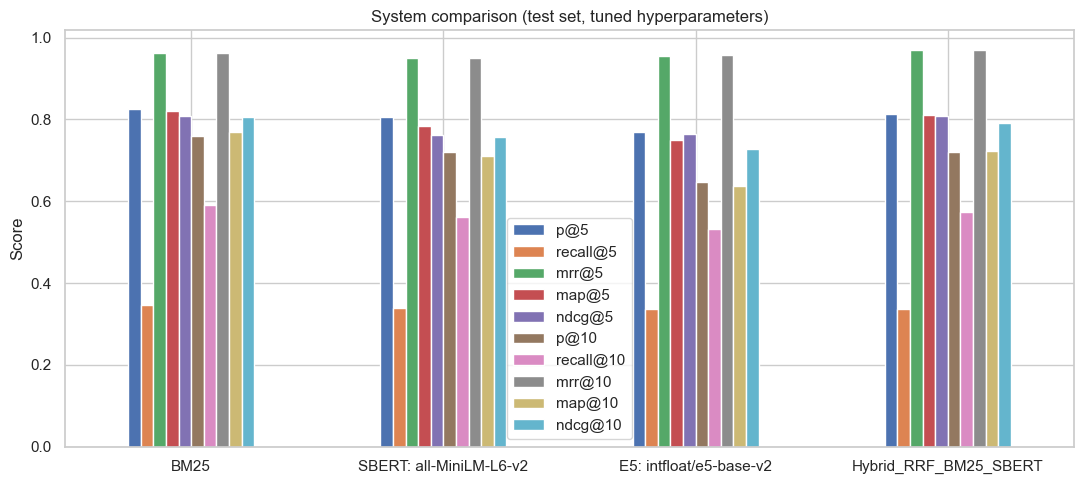

Best system on test (nDCG@10): BM25
ndcg@10        0.805096
mrr@10         0.961905
recall@10      0.591463
latency_ms    36.328647
Name: 0, dtype: object


In [15]:
# Aggregate metric view
metric_cols = [
    "p@5", "recall@5", "mrr@5", "map@5", "ndcg@5",
    "p@10", "recall@10", "mrr@10", "map@10", "ndcg@10", "latency_ms",
]

plot_labels = [
    "BM25",
    f"SBERT: {sbert_model_name}",
    f"E5: {e5_model_name}",
    HYBRID_SYSTEM_NAME,
]

display(
    summary[metric_cols]
    .style.format({c: "{:.4f}" for c in metric_cols if c != "latency_ms"})
    .format({"latency_ms": "{:.2f}"})
)

plot_metrics = [c for c in metric_cols if c != "latency_ms"]
ax = summary.set_index(pd.Index(plot_labels))[plot_metrics].plot(
    kind="bar", figsize=(11, 5), rot=0
)
ax.set_title("System comparison (test set, tuned hyperparameters)")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

summary_named = summary.reset_index().rename(columns={"index": "system"})
summary_named["system"] = plot_labels
best_row = summary_named.sort_values("ndcg@10", ascending=False).iloc[0]
print("Best system on test (nDCG@10):", best_row["system"])
print(best_row[["ndcg@10", "mrr@10", "recall@10", "latency_ms"]])


In [16]:
# Per-query win/loss analysis + export artifacts
hybrid_col = "hybrid_ndcg"

merged = bm25_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "bm25_ndcg"})
merged = merged.merge(
    sbert_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "sbert_ndcg"}),
    on="query_id",
    how="outer",
)
merged = merged.merge(
    e5_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "e5_ndcg"}),
    on="query_id",
    how="outer",
)
merged = merged.merge(
    hybrid_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": hybrid_col}),
    on="query_id",
    how="outer",
)

merged = merged.fillna(0)
winner_cols = ["bm25_ndcg", "sbert_ndcg", "e5_ndcg", hybrid_col]
merged["winner"] = merged[winner_cols].idxmax(axis=1)
print("Winner counts by query (test set):")
print(merged["winner"].value_counts())

os.makedirs(BENCHMARK_DIR, exist_ok=True)
os.makedirs(MODEL_ARTIFACT_DIR, exist_ok=True)

np.save(os.path.join(MODEL_ARTIFACT_DIR, "sbert_embeddings.npy"), sbert_embeddings)
np.save(os.path.join(MODEL_ARTIFACT_DIR, "e5_embeddings.npy"), e5_embeddings)
summary_named.to_csv(os.path.join(BENCHMARK_DIR, "results_summary.csv"), index=False)

all_per_query = pd.concat(
    [bm25_perq, sbert_perq, e5_perq, hybrid_perq], axis=0, ignore_index=True
)
all_per_query.to_csv(os.path.join(BENCHMARK_DIR, "results_per_query.csv"), index=False)

bm25_tune_df.to_csv(os.path.join(BENCHMARK_DIR, "tuning_bm25_dev.csv"), index=False)
sbert_tune_df.to_csv(os.path.join(BENCHMARK_DIR, "tuning_sbert_dev.csv"), index=False)
e5_tune_df.to_csv(os.path.join(BENCHMARK_DIR, "tuning_e5_dev.csv"), index=False)
hybrid_tune_df.to_csv(os.path.join(BENCHMARK_DIR, "tuning_hybrid_rrf_dev.csv"), index=False)

print("Saved artifacts to:")
print("-", MODEL_ARTIFACT_DIR)
print("-", BENCHMARK_DIR)


Winner counts by query (test set):
winner
bm25_ndcg      39
sbert_ndcg     16
e5_ndcg         9
hybrid_ndcg     6
Name: count, dtype: int64
Saved artifacts to:
- artifacts
- benchmark
